# 데이터 탐색 및 시각화용

- train.csv 파일 불러와서 데이터 형태 확인(행/열)
- 타겟 변수(y)의 히스토그램을 그려보고 이상치(Outlier)가 있는지 확인
- 결측치(Missing Value)가 있는지 확인
- 결과물 : 학습 데이터 이해 및 전처리 방향성/아이디어 정립

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
train_path = 'C:/rokey/PROJECT_Data_analyze/my-mercedes-project/data/raw/mercedes-benz-greener-manufacturing/train.csv/train.csv'
train_df = pd.read_csv(train_path)

# 데이터 정보 확인
print("Train 데이터 세트 모양:", train_df.shape)
print("=" * 50)
print(train_df.info())
print("=" * 50)
print(train_df.describe())
print("=" * 50)
print(train_df.head())
print("=" * 50)
print("결측치 총 개수:",train_df.isnull().sum())
print("=" * 50)


Train 데이터 세트 모양: (4209, 378)
<class 'pandas.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 378 entries, ID to X385
dtypes: float64(1), int64(369), str(8)
memory usage: 12.1 MB
None
                ID            y          X10     X11          X12  \
count  4209.000000  4209.000000  4209.000000  4209.0  4209.000000   
mean   4205.960798   100.669318     0.013305     0.0     0.075077   
std    2437.608688    12.679381     0.114590     0.0     0.263547   
min       0.000000    72.110000     0.000000     0.0     0.000000   
25%    2095.000000    90.820000     0.000000     0.0     0.000000   
50%    4220.000000    99.150000     0.000000     0.0     0.000000   
75%    6314.000000   109.010000     0.000000     0.0     0.000000   
max    8417.000000   265.320000     1.000000     0.0     1.000000   

               X13          X14          X15          X16          X17  ...  \
count  4209.000000  4209.000000  4209.000000  4209.000000  4209.000000  ...   
mean      0.057971     0.4281

In [46]:
# 범주형 변수(X0~X8)의 분포 및 고유값 개수 확인하기
categorical_cols = ['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']
for column in categorical_cols:
    print(f"열 이름: {column}")
    print(train_df[column].value_counts())
    print("타겟의 수:", train_df[column].nunique())
    print("=" * 50)

열 이름: X0
X0
z     360
ak    349
y     324
ay    313
t     306
x     300
o     269
f     227
n     195
w     182
j     181
az    175
aj    151
s     106
ap    103
h      75
d      73
al     67
v      36
af     35
ai     34
m      34
e      32
ba     27
at     25
a      21
ax     19
am     18
aq     18
i      18
u      17
l      16
aw     16
ad     14
k      11
b      11
au     11
as     10
r      10
bc      6
ao      4
c       3
q       2
aa      2
ac      1
g       1
ab      1
Name: count, dtype: int64
타겟의 수: 47
열 이름: X1
X1
aa    833
s     598
b     592
l     590
v     408
r     251
i     203
a     143
c     121
o      82
w      52
z      46
u      37
e      33
m      32
t      31
h      29
y      23
f      23
j      22
n      19
k      17
p       9
g       6
d       3
q       3
ab      3
Name: count, dtype: int64
타겟의 수: 27
열 이름: X2
X2
as    1659
ae     496
ai     415
m      367
ak     265
r      153
n      137
s       94
f       87
e       81
aq      63
ay      54
a       47
t       2

In [47]:
# 분산이 0인 열 확인하기
zero_variance_cols = [col for col in train_df.columns if train_df[col].nunique() == 1]
print("분산이 0인 열:", zero_variance_cols)

분산이 0인 열: ['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X289', 'X290', 'X293', 'X297', 'X330', 'X347']


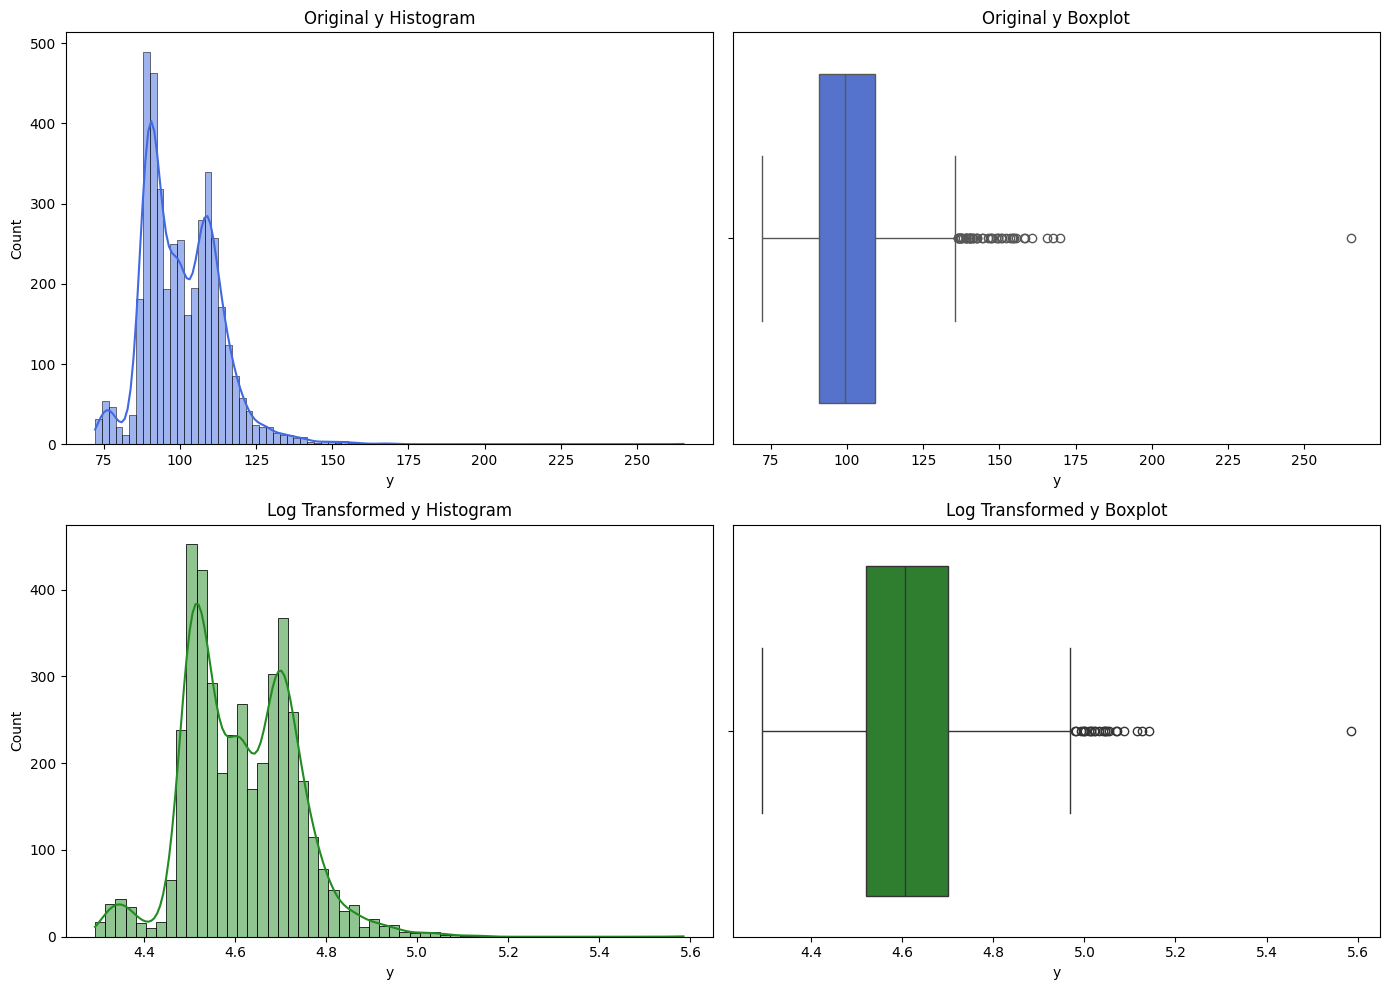

In [48]:
# 데이터 시각화
# y의 분포 시각화(원본 vs 로그 변환)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(train_df['y'], kde=True, ax=axes[0, 0], color='royalblue')
axes[0, 0].set_title('Original y Histogram')

sns.boxplot(x=train_df['y'], ax=axes[0, 1], color='royalblue')
axes[0, 1].set_title('Original y Boxplot')

sns.histplot(np.log1p(train_df['y']), kde=True, ax=axes[1, 0], color='forestgreen')
axes[1, 0].set_title('Log Transformed y Histogram')

sns.boxplot(x=np.log1p(train_df['y']), ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title('Log Transformed y Boxplot')
plt.tight_layout()
plt.show()

In [49]:
# 이상치 기준 계산하기

# 1. 사분위수 구하기 (Q1: 25%, Q3: 75%)
Q1 = train_df['y'].quantile(0.25)
Q3 = train_df['y'].quantile(0.75)

# 2. IQR (사분위간 범위) 계산
IQR = Q3 - Q1

# 3. 정상 범위의 상한선(마지노선) 계산
upper_bound = Q3 + (1.5 * IQR)

# # 4. 하한선 계산
# lower_bound = Q1 - (1.5 * IQR)

# 5. 수학적 기준선 출력
print(f"하위 25% 지점(Q1): {Q1:.2f}초")
print(f"상위 75% 지점(Q3): {Q3:.2f}초")
print(f"IQR (상자 길이): {IQR:.2f}초")
print(f"🎯 정상 데이터 마지노선 상한선: {upper_bound:.2f}초")
print("=" * 50)

# 6. 기준선을 넘는 이상치 데이터 필터링
outliers = train_df[train_df['y'] > upper_bound]
print(f"통계학적 이상치 개수: 총 {len(outliers)}개 (전체 데이터의 {len(outliers)/len(train_df)*100:.2f}%)")

print(outliers[['ID', 'y']].sort_values(by='y', ascending=False).head(10))

하위 25% 지점(Q1): 90.82초
상위 75% 지점(Q3): 109.01초
IQR (상자 길이): 18.19초
🎯 정상 데이터 마지노선 상한선: 136.30초
통계학적 이상치 개수: 총 50개 (전체 데이터의 1.19%)
        ID       y
883   1770  265.32
342    681  169.91
1459  2903  167.45
3133  6273  165.52
1203  2396  160.87
889   1784  158.53
2735  5471  158.23
3744  7500  155.62
429    836  154.87
1060  2111  154.43


In [ ]:
# 이상치 여부 확인 라벨(is_outlier) 추가
# 매우 옆으로 긴 데이터셋이므로, 원본 데이터프레임을 복사하여 작업
# 데이터프레임 파편화 방지
df_processed = train_df.copy()

Q1 = df_processed['y'].quantile(0.25)
Q3 = df_processed['y'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + (1.5 * IQR)

df_processed['is_delay'] = (df_processed['y'] > upper_bound).astype(int)

print(f"[1단계 완료] 'is_delay' 라벨 생성 완료.")
print(df_processed['is_delay'].value_counts())
print("-" * 50)
print(df_processed[['ID', 'y', 'is_delay']].head(10))

[1단계 완료] 'is_delay' 라벨 생성 완료.
is_delay
0    4159
1      50
Name: count, dtype: int64
--------------------------------------------------
   ID       y  is_delay
0   0  130.81         0
1   6   88.53         0
2   7   76.26         0
3   9   80.62         0
4  13   78.02         0
5  18   92.93         0
6  24  128.76         0
7  25   91.91         0
8  27  108.67         0
9  30  126.99         0
